In [1]:
%pip install -q --no-warn-script-location sysidentpy numpy scipy torch scikit-learn

import time
import os
from pathlib import Path

import scipy.io as sio
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sysidentpy.neural_network import NARXNN
from sysidentpy.basis_function import Polynomial
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(device)}")
elif device.type == "mps":
    print("GPU: Apple MPS")

try:
    from google.colab import drive
    drive.mount("/content/drive")
    data_path = Path("/content/drive/MyDrive/Benchmark_EEG_small/Benchmark_EEG_small.mat")
except ImportError:
    data_path = Path("./Benchmark_EEG_medium/Benchmark_EEG_medium.mat")

data = sio.loadmat(data_path, simplify_cells=True)
eeg_data = data["EEGdata"]

u_list = []
y_list = []

# Iterate over all participants
# The input (angle) and output (comp) are matrices with dimensions: [M realizations, P periods, N samples]
for s in range(len(eeg_data)):
    u_subj = eeg_data[s]["angle"]
    y_subj = eeg_data[s]["comp"]
    
    # Flatten realizations and periods into a single "trials" dimension
    M, P, N = u_subj.shape
    u_list.append(u_subj.reshape(M * P, N))
    y_list.append(y_subj.reshape(M * P, N))

u_trials = np.vstack(u_list).astype(np.float32)   # float32 subito: -50% RAM vs float64
y_trials = np.vstack(y_list).astype(np.float32)

# Libera le liste intermedie e i dati grezzi — non servono più
del u_list, y_list, data, eeg_data
trial_len = u_trials.shape[1]
n_trials = u_trials.shape[0]

print(f"Trials: {n_trials}  |  Lunghezza trial: {trial_len}  |  Campioni totali: {u_trials.size:,}")

Note: you may need to restart the kernel to use updated packages.
Device: mps
GPU: Apple MPS
Trials: 14700  |  Lunghezza trial: 2048  |  Campioni totali: 30,105,600


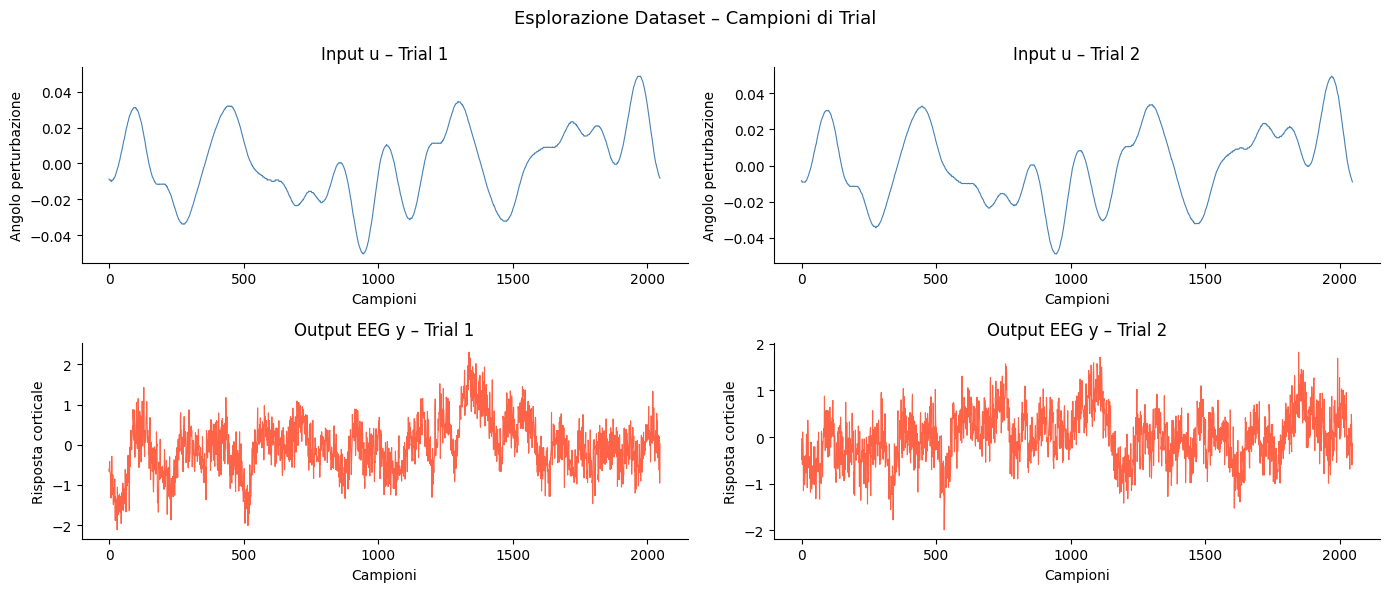

u – media: -0.0000  std: 0.0206  range: [-0.056, 0.056]
y – media: -0.0001  std: 0.7738  range: [-11.164, 7.306]


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
fig.suptitle("Esplorazione Dataset – Campioni di Trial", fontsize=13)

for i, ax in enumerate(axes[0]):
    ax.plot(u_trials[i], color='steelblue', lw=0.8)
    ax.set_title(f"Input u – Trial {i+1}")
    ax.set_xlabel("Campioni")
    ax.set_ylabel("Angolo perturbazione")

for i, ax in enumerate(axes[1]):
    ax.plot(y_trials[i], color='tomato', lw=0.8)
    ax.set_title(f"Output EEG y – Trial {i+1}")
    ax.set_xlabel("Campioni")
    ax.set_ylabel("Risposta corticale")

plt.tight_layout()
plt.savefig("data_exploration.png", dpi=120)
plt.show()

# Statistiche di base
print(f"u – media: {u_trials.mean():.4f}  std: {u_trials.std():.4f}  range: [{u_trials.min():.3f}, {u_trials.max():.3f}]")
print(f"y – media: {y_trials.mean():.4f}  std: {y_trials.std():.4f}  range: [{y_trials.min():.3f}, {y_trials.max():.3f}]")


In [3]:
# Split 70/15/15% per trial interi — nessun data leakage temporale
n_train = int(np.floor(0.70 * n_trials))
n_val   = int(np.floor(0.15 * n_trials))
n_test  = n_trials - n_train - n_val

idx      = np.random.permutation(n_trials)
train_idx = idx[:n_train]
val_idx   = idx[n_train:n_train + n_val]
test_idx  = idx[n_train + n_val:]

# Usa view numpy (np.ascontiguousarray solo se serve) — nessuna copia
u_train_trials = u_trials[train_idx]
y_train_trials = y_trials[train_idx]
u_val_trials   = u_trials[val_idx]
y_val_trials   = y_trials[val_idx]
u_test_trials  = u_trials[test_idx]
y_test_trials  = y_trials[test_idx]

# Libera l'array originale — gli split sono le uniche copie necessarie
del u_trials, y_trials

print(f"Train: {n_train} trial  Val: {n_val}  Test: {n_test}")
print(f"RAM stimata dati: {(u_train_trials.nbytes + y_train_trials.nbytes + u_val_trials.nbytes + y_val_trials.nbytes + u_test_trials.nbytes + y_test_trials.nbytes) / 1024**2:.0f} MB")


Train : 10290 trial (21073920 campioni)
Val   : 2205   trial (4515840 campioni)
Test  : 2205  trial (4515840 campioni)


In [4]:
scaler_u = StandardScaler()
scaler_y = StandardScaler()

# fit sul training flat — usa reshape(-1,1) che è una view, non copia
u_train_s = scaler_u.fit_transform(u_train_trials.reshape(-1, 1)).astype(np.float32)
y_train_s = scaler_y.fit_transform(y_train_trials.reshape(-1, 1)).astype(np.float32)

def scale_trials(scaler, trials_2d):
    """Scala e converte in float32 in un solo passaggio — nessuna copia float64."""
    return scaler.transform(trials_2d.reshape(-1, 1)).astype(np.float32).reshape(trials_2d.shape)

u_val_trials_s  = scale_trials(scaler_u, u_val_trials)
y_val_trials_s  = scale_trials(scaler_y, y_val_trials)
u_test_trials_s = scale_trials(scaler_u, u_test_trials)
y_test_trials_s = scale_trials(scaler_y, y_test_trials)
utrain_trials_s = scale_trials(scaler_u, u_train_trials)
ytrain_trials_s = scale_trials(scaler_y, y_train_trials)

print(f"Normalizzazione OK — dtype: {utrain_trials_s.dtype}  shape: {utrain_trials_s.shape}")
print(f"RAM scaled arrays: {(utrain_trials_s.nbytes + ytrain_trials_s.nbytes + u_val_trials_s.nbytes + y_val_trials_s.nbytes + u_test_trials_s.nbytes + y_test_trials_s.nbytes) / 1024**2:.0f} MB")


Normalizzazione OK  — train (10290, 2048)  val (2205, 2048)  test (2205, 2048)


In [ ]:
NY = 15
NU = 15
DEGREE = 1
H1 = 128
EPOCHS = 300
LEARNING_RATE = 1e-3
INPUT_SIZE = NY + NU  # 30

# ── parametri adattivi per device ──────────────────────────────────────────
if device.type == "cuda":
    BATCH_SIZE   = 256   # T4 ha 16 GB VRAM
    NUM_WORKERS  = 2     # Colab: fork OK su Linux
    PIN_MEMORY   = True  # accelera CPU→GPU transfer
    USE_AMP      = True  # mixed precision fp16 su T4 tensor cores (~2x speedup)
elif device.type == "mps":
    BATCH_SIZE   = 128   # M4: memoria unificata condivisa con OS
    NUM_WORKERS  = 0     # Mac: fork causa hang
    PIN_MEMORY   = False # MPS: pin_memory non ha senso su memoria unificata
    USE_AMP      = False # MPS: autocast non supportato
else:
    BATCH_SIZE   = 64
    NUM_WORKERS  = 0
    PIN_MEMORY   = False
    USE_AMP      = False

print(f"Config: BATCH={BATCH_SIZE}  WORKERS={NUM_WORKERS}  PIN={PIN_MEMORY}  AMP={USE_AMP}")

class SimpleNARXNet(nn.Module):
    """MLP a due hidden layer."""
    def __init__(self, input_size=INPUT_SIZE, hidden=H1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),     nn.Tanh(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

net = SimpleNARXNet().to(device)
try:
    net = torch.compile(net, mode="default")
    print("torch.compile: attivo")
except Exception:
    print("torch.compile: non disponibile")

print(net)
print(f"Parametri: {count_params(net):,}")


torch.compile: attivo
OptimizedModule(
  (_orig_mod): NARXResNet(
    (input_proj): Linear(in_features=30, out_features=128, bias=True)
    (ln0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (drop): Dropout(p=0.1, inplace=False)
    (res1): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (2): Tanh()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (res2): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (2): Tanh()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (res3): Sequential(
      (0): Linear(in_features=128, out_

In [ ]:
# Cella 3: Inizializzazione modello
input_size = NY + NU
# Inizializziamo il modello su cpu perché SysIdentPy invia i tensori su cpu
net = SimpleNARXNet().to(device)

model = NARXNN(
    net=net,
    ylag=NY,
    xlag=NU,
    basis_function=Polynomial(degree=DEGREE),
    loss_func='mse_loss',
    optimizer='Adam',
    optim_params={},
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    device=device.type if device.type == "cuda" else "cpu",  # SysIdentPy vuole esattamente la stringa 'cpu' o 'cuda'
    verbose=False,
)

print(f"NARX input size: {input_size}")

NARX input size: 30


In [7]:
print("Training NARX...")
t0 = time.perf_counter()
model.fit(X=u_train_s, y=y_train_s)
train_time_s = time.perf_counter() - t0
print(f"Training completed in {train_time_s:.2f} s")


Training NARX...


KeyboardInterrupt: 

In [8]:
def predict_per_trial(model, u_trials_s, y_trials_s, steps_ahead=None):
    preds_list = []
    for i in range(len(u_trials_s)):
        u_t = u_trials_s[i].reshape(-1, 1)
        y_t = y_trials_s[i].reshape(-1, 1)
        yhat_t = model.predict(X=u_t, y=y_t, steps_ahead=steps_ahead)
        preds_list.append(np.asarray(yhat_t).ravel())
    return preds_list

def evaluate_per_trial(preds_list, y_trials_s, scaler_y):
    vafs, nrmses, rmses = [], [], []
    for i, yhat_s in enumerate(preds_list):
        y_true_s = y_trials_s[i].ravel()
        n = len(yhat_s)
        y_true_s = y_true_s[-n:]
        y_true = scaler_y.inverse_transform(y_true_s.reshape(-1, 1)).ravel()
        y_pred = scaler_y.inverse_transform(yhat_s.reshape(-1, 1)).ravel()
        var_true = np.var(y_true)
        if var_true > 0:
            vafs.append((1 - np.var(y_true - y_pred) / var_true) * 100.0)
        rmse_v = np.sqrt(mean_squared_error(y_true, y_pred))
        rmses.append(rmse_v)
        denom = np.max(y_true) - np.min(y_true)
        if denom > 0:
            nrmses.append(rmse_v / denom)
    return {
        'VAF (%)': np.mean(vafs),
        'NRMSE': np.mean(nrmses),
        'RMSE': np.mean(rmses),
    }

val_1step_preds = predict_per_trial(model, u_val_trials_s, y_val_trials_s, steps_ahead=1)
val_free_preds  = predict_per_trial(model, u_val_trials_s, y_val_trials_s, steps_ahead=None)
test_1step_preds = predict_per_trial(model, u_test_trials_s, y_test_trials_s, steps_ahead=1)
test_free_preds  = predict_per_trial(model, u_test_trials_s, y_test_trials_s, steps_ahead=None)

res_val_1step  = evaluate_per_trial(val_1step_preds,  y_val_trials_s,  scaler_y)
res_val_free   = evaluate_per_trial(val_free_preds,   y_val_trials_s,  scaler_y)
res_test_1step = evaluate_per_trial(test_1step_preds, y_test_trials_s, scaler_y)
res_test_free  = evaluate_per_trial(test_free_preds,  y_test_trials_s, scaler_y)

print('\nRISULTATI MODELLO STANDARD')
for name, r in [
    ('val 1-step', res_val_1step),
    ('val free-run', res_val_free),
    ('test 1-step', res_test_1step),
    ('test free-run', res_test_free),
]:
    print(f"[{name}] VAF={r['VAF (%)']:.2f}% NRMSE={r['NRMSE']:.4f} RMSE={r['RMSE']:.5f}")

KeyboardInterrupt: 

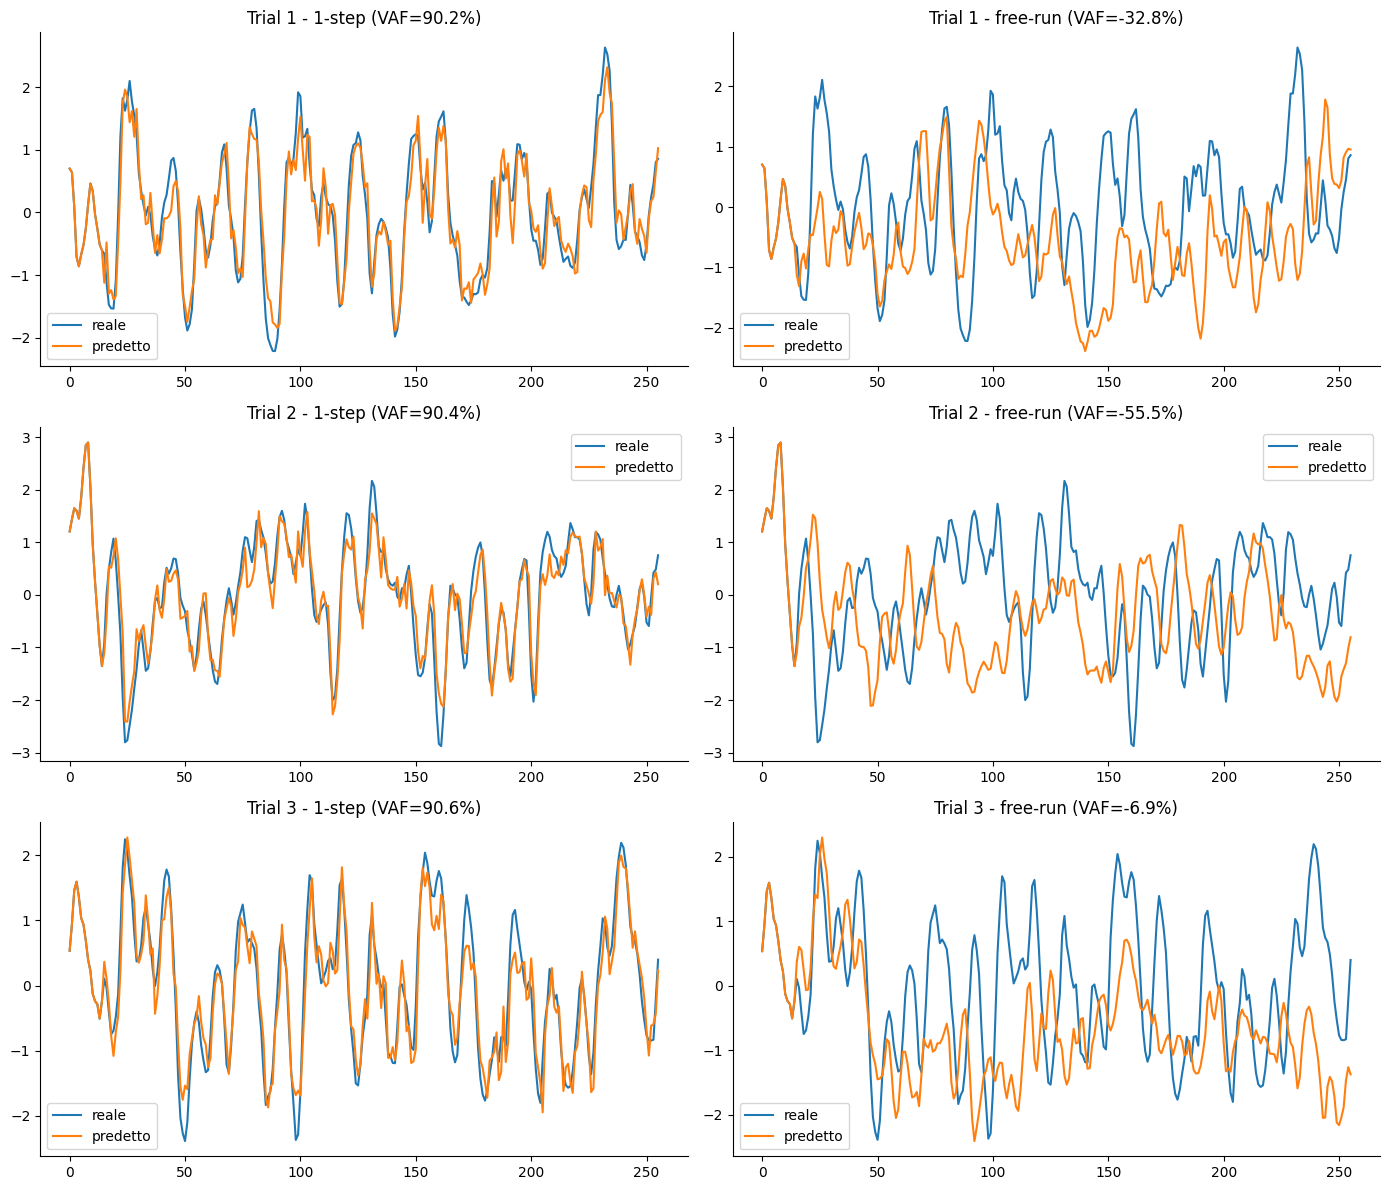

In [ ]:
n_show = min(3, len(test_free_preds))
fig, axes = plt.subplots(n_show, 2, figsize=(14, 4 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for i in range(n_show):
    for j, (preds, label) in enumerate([(test_1step_preds, '1-step'), (test_free_preds, 'free-run')]):
        yhat_s = preds[i]
        y_true_s = y_test_trials_s[i].ravel()[-len(yhat_s):]
        y_true = scaler_y.inverse_transform(y_true_s.reshape(-1, 1)).ravel()
        y_pred = scaler_y.inverse_transform(yhat_s.reshape(-1, 1)).ravel()
        vaf_v = (1 - np.var(y_true - y_pred) / np.var(y_true)) * 100
        axes[i, j].plot(y_true, label='reale')
        axes[i, j].plot(y_pred, label='predetto')
        axes[i, j].set_title(f'Trial {i+1} - {label} (VAF={vaf_v:.1f}%)')
        axes[i, j].legend()
plt.tight_layout()
plt.show()

In [7]:
import torch.optim as optim


def _build_regressor_matrix(y_arr, u_arr, maxlag, NY, NU):
    """Costruisce la matrice regressori (T-maxlag, NY+NU) con numpy puro."""
    t_range = np.arange(maxlag, len(y_arr))
    Y_lags  = np.stack([y_arr[t_range - k] for k in range(1, NY + 1)], axis=1)
    U_lags  = np.stack([u_arr[t_range - k] for k in range(1, NU + 1)], axis=1)
    return np.concatenate([Y_lags, U_lags], axis=1).astype(np.float32)


class NARXTrialDataset(Dataset):
    """Zero-copy Dataset: torch.from_numpy condivide la memoria numpy."""
    def __init__(self, X_np, Y_np, n_valid):
        self.X = torch.from_numpy(np.ascontiguousarray(X_np))
        self.Y = torch.from_numpy(np.ascontiguousarray(Y_np))
        self.n = n_valid
    def __len__(self):
        return self.n
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


def build_epoch_arrays(net, us_trials, ys_trials, NY, NU, p_free,
                        X_buf, Y_buf):
    """Riempie buffer pre-allocati — zero allocazioni per epoca."""
    maxlag = max(NY, NU)
    ptr    = 0
    net.eval()
    with torch.no_grad():
        for i in range(us_trials.shape[0]):
            y_np = ys_trials[i].ravel().astype(np.float32)
            u_np = us_trials[i].ravel().astype(np.float32)
            T, n = len(y_np), len(y_np) - maxlag

            if p_free == 0.0:
                X_buf[ptr:ptr+n] = _build_regressor_matrix(y_np, u_np, maxlag, NY, NU)
                Y_buf[ptr:ptr+n] = y_np[maxlag:]
            else:
                rand_mask = np.random.random(n) < p_free
                ybuf      = y_np.copy()
                for j, t in enumerate(range(maxlag, T)):
                    if rand_mask[j]:
                        reg    = torch.from_numpy(
                            np.concatenate([ybuf[t-NY:t][::-1],
                                            u_np[t-NU:t][::-1]]).reshape(1, -1)
                        ).to(device)
                        ybuf[t] = net(reg).item()
                X_buf[ptr:ptr+n] = _build_regressor_matrix(ybuf, u_np, maxlag, NY, NU)
                Y_buf[ptr:ptr+n] = y_np[maxlag:]

            ptr += n
    return ptr


def train_scheduled_sampling(net, us_trials, ys_trials, NY, NU,
                              epochs=300, lr=1e-3, batch_size=BATCH_SIZE,
                              ss_start=0.0, ss_end=0.4, warmup_epochs=50,
                              noise_std=0.02):
    net = net.to(device)
    optimizer = optim.Adam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=15
    )
    criterion = nn.MSELoss()

    # AMP scaler — attivo solo su CUDA (T4 tensor cores fp16)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    loss_history = []
    best_loss, best_state = float("inf"), None

    # Pre-alloca buffer UNA VOLTA — riusati ad ogni epoca (~1.6 GB risparmio)
    maxlag     = max(NY, NU)
    total_rows = us_trials.shape[0] * (us_trials.shape[1] - maxlag)
    X_buf = np.empty((total_rows, NY + NU), dtype=np.float32)
    Y_buf = np.empty(total_rows,            dtype=np.float32)
    print(f"Buffer pre-allocati: {(X_buf.nbytes + Y_buf.nbytes) / 1024**2:.0f} MB")

    for epoch in range(epochs):
        if epoch < warmup_epochs:
            p_free = 0.0
        else:
            progress = (epoch - warmup_epochs) / max(epochs - warmup_epochs - 1, 1)
            sig    = 1.0 / (1.0 + np.exp(-8.0 * (progress - 0.5)))
            p_free = ss_start + (ss_end - ss_start) * sig

        n_valid = build_epoch_arrays(net, us_trials, ys_trials, NY, NU,
                                     p_free, X_buf, Y_buf)
        X_np = X_buf[:n_valid]
        Y_np = Y_buf[:n_valid]

        if noise_std > 0:
            X_np = X_np + (np.random.randn(*X_np.shape).astype(np.float32) * noise_std)

        ds     = NARXTrialDataset(X_np, Y_np, n_valid)
        loader = DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=True,
            num_workers=NUM_WORKERS,
            pin_memory=PIN_MEMORY,
            persistent_workers=(NUM_WORKERS > 0),
        )

        net.train()
        ep_loss, nb = 0.0, 0
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=PIN_MEMORY)
            yb = yb.unsqueeze(1).to(device, non_blocking=PIN_MEMORY)
            optimizer.zero_grad(set_to_none=True)

            # AMP: forward + loss in fp16 su CUDA, fp32 su MPS/CPU
            with torch.autocast(device_type=device.type,
                                 dtype=torch.float16,
                                 enabled=USE_AMP):
                loss = criterion(net(xb), yb)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(net.parameters(), 0.5)
            scaler.step(optimizer)
            scaler.update()

            ep_loss += loss.item(); nb += 1

        # Libera cache CUDA se disponibile
        if device.type == "cuda":
            torch.cuda.empty_cache()

        avg_loss = ep_loss / max(nb, 1)
        scheduler.step(avg_loss)
        loss_history.append(avg_loss)

        if avg_loss < best_loss:
            best_loss  = avg_loss
            best_state = {k: v.clone() for k, v in net.state_dict().items()}

    if best_state is not None:
        net.load_state_dict(best_state)
        print(f"Ripristinato best checkpoint (loss={best_loss:.6f})")

    return net, loss_history


def predict_free_run_manual(net, u_trial_s, y_trial_s, NY, NU):
    net.eval()
    net = net.to(device)
    T       = len(u_trial_s)
    max_lag = max(NY, NU)
    y_buf   = y_trial_s.ravel().astype(np.float32).copy()
    u_arr   = u_trial_s.ravel().astype(np.float32)
    preds   = np.empty(T - max_lag, dtype=np.float32)
    with torch.no_grad():
        for j, t in enumerate(range(max_lag, T)):
            reg      = torch.from_numpy(
                np.concatenate([y_buf[t-NY:t][::-1],
                                u_arr[t-NU:t][::-1]]).reshape(1, -1)
            ).to(device)
            yhat     = net(reg).item()
            y_buf[t] = yhat
            preds[j] = yhat
    return preds


In [ ]:
torch.manual_seed(SEED)
np.random.seed(SEED)
net_ss = SimpleNARXNet().to(device)

try:
    net_ss = torch.compile(net_ss, mode="default")
    print("torch.compile: attivo su net_ss")
except Exception:
    pass

print(f"Parametri SS model: {count_params(net_ss):,}")
print(f"Training con Scheduled Sampling su {device.type.upper()}...")
t0 = time.perf_counter()
net_ss, ss_loss = train_scheduled_sampling(
    net_ss, utrain_trials_s, ytrain_trials_s,
    NY=NY, NU=NU,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    ss_start=0.0,
    ss_end=0.4,
    warmup_epochs=50,
    noise_std=0.02,
)
print(f"Training SS completato in {time.perf_counter() - t0:.1f} s")


torch.compile: attivo su net_ss
Parametri SS model: 104,961
Training con Scheduled Sampling...


KeyboardInterrupt: 

In [ ]:
def eval_ss_model(net_ss, u_trials_s, y_trials_s, scaler_y, NY, NU):
    vafs, nrmses = [], []
    for i in range(len(u_trials_s)):
        yhat_s = predict_free_run_manual(net_ss, u_trials_s[i], y_trials_s[i], NY, NU)
        n = len(yhat_s)
        y_true_s = y_trials_s[i].ravel()[-n:]
        y_true = scaler_y.inverse_transform(y_true_s.reshape(-1, 1)).ravel()
        y_pred = scaler_y.inverse_transform(yhat_s.reshape(-1, 1)).ravel()
        vt = np.var(y_true)
        if vt > 0:
            vafs.append((1 - np.var(y_true - y_pred) / vt) * 100)
        denom = np.max(y_true) - np.min(y_true)
        if denom > 0:
            nrmses.append(np.sqrt(np.mean((y_true - y_pred) ** 2)) / denom)
    return np.mean(vafs), np.mean(nrmses)

vaf_val, nrmse_val = eval_ss_model(net_ss, u_val_trials_s, y_val_trials_s, scaler_y, NY, NU)
vaf_test, nrmse_test = eval_ss_model(net_ss, u_test_trials_s, y_test_trials_s, scaler_y, NY, NU)

print('\nRISULTATI SCHEDULED SAMPLING')
print(f"Val  -> VAF={vaf_val:.2f}% NRMSE={nrmse_val:.4f}")
print(f"Test -> VAF={vaf_test:.2f}% NRMSE={nrmse_test:.4f}")

plt.figure(figsize=(10, 3))
plt.plot(ss_loss)
plt.yscale('log')
plt.title('Loss training Scheduled Sampling')
plt.tight_layout()
plt.show()

NameError: name 'net_ss' is not defined

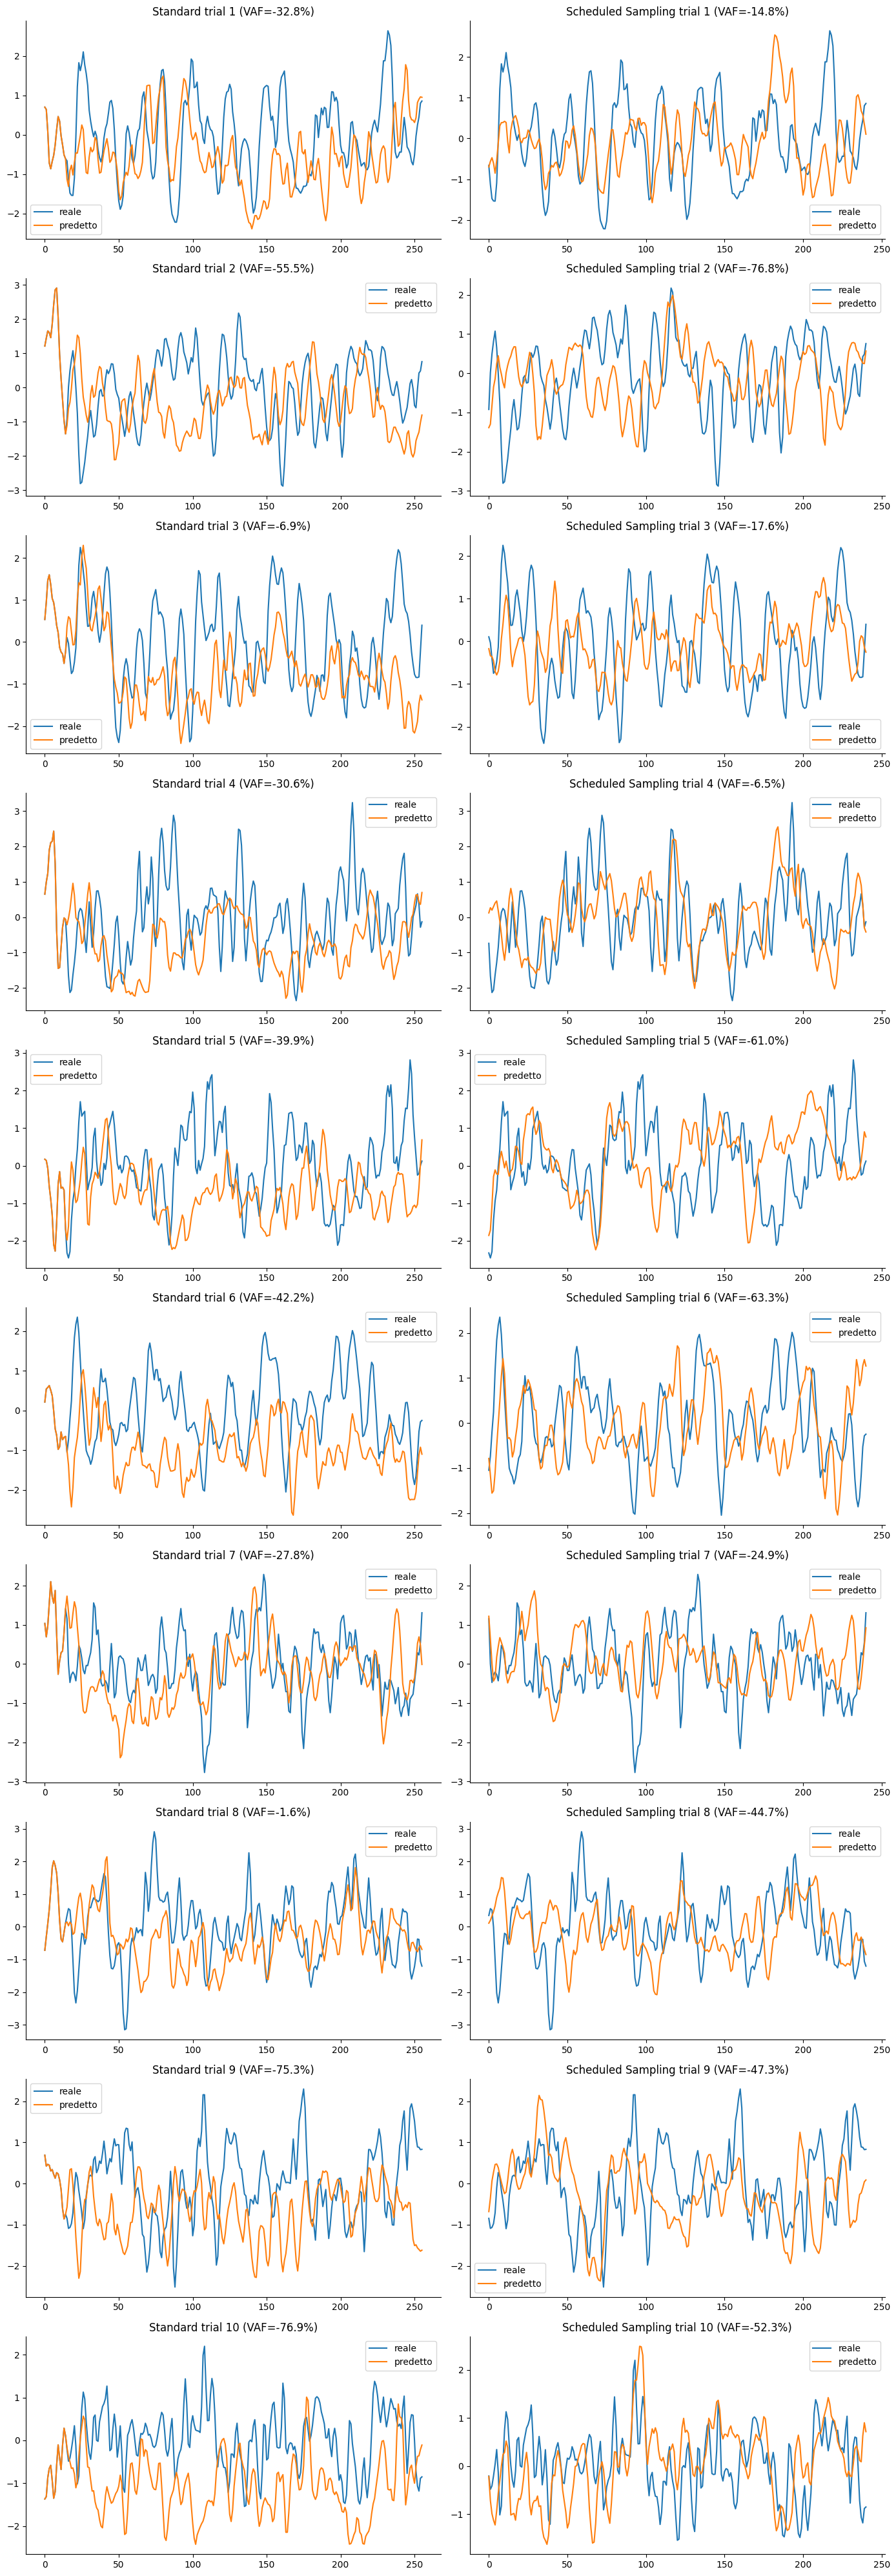

In [ ]:
n_show = min(10, len(u_test_trials_s))
fig, axes = plt.subplots(n_show, 2, figsize=(14, 4 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for i in range(n_show):
    yhat_std_s = test_free_preds[i]
    yt_s = y_test_trials_s[i].ravel()[-len(yhat_std_s):]
    yt_std = scaler_y.inverse_transform(yt_s.reshape(-1, 1)).ravel()
    yp_std = scaler_y.inverse_transform(yhat_std_s.reshape(-1, 1)).ravel()
    vaf_std = (1 - np.var(yt_std - yp_std) / np.var(yt_std)) * 100

    yhat_ss_s = predict_free_run_manual(net_ss, u_test_trials_s[i], y_test_trials_s[i], NY, NU)
    yt_s2 = y_test_trials_s[i].ravel()[-len(yhat_ss_s):]
    yt_ss = scaler_y.inverse_transform(yt_s2.reshape(-1, 1)).ravel()
    yp_ss = scaler_y.inverse_transform(yhat_ss_s.reshape(-1, 1)).ravel()
    vaf_ss = (1 - np.var(yt_ss - yp_ss) / np.var(yt_ss)) * 100

    axes[i, 0].plot(yt_std, label='reale')
    axes[i, 0].plot(yp_std, label='predetto')
    axes[i, 0].set_title(f'Standard trial {i+1} (VAF={vaf_std:.1f}%)')
    axes[i, 0].legend()

    axes[i, 1].plot(yt_ss, label='reale')
    axes[i, 1].plot(yp_ss, label='predetto')
    axes[i, 1].set_title(f'Scheduled Sampling trial {i+1} (VAF={vaf_ss:.1f}%)')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()